# Lab Experiment 5: Linear Regression through Gradient Descent
---

## Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real world dataset.

## Objectives
1. To understand the concept of Gradient Descent for optimizing a Linear Regression model.
2. To preprocess the dataset before model training.
3. To implement Linear Regression using Gradient Descent.
4. To analyze the convergence of the loss function during training.
5. To evaluate the model using standard regression metrics.

## Dataset
- **Dataset Name:** Student Performance Dataset
- **Source:** UCI Machine Learning Repository
- **Dataset Link:** https://archive.ics.uci.edu/dataset/320/student+performance

The dataset contains information about secondary school students (Mathematics course), including demographic details, family background, study habits, and three grades (`G1`, `G2`, `G3`). We will predict the **final grade `G3`** using the remaining attributes.


## Task 1: Download and Load the Dataset

The dataset file `student-mat.csv` (Mathematics course students) is loaded using `pandas`. The file uses `;` as the separator instead of the usual comma.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("student-mat.csv", sep=";")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [17]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

## Task 2: Data Preprocessing

This involves three steps:
1. **Handling missing values** – check if any column has null values.
2. **Encoding categorical variables** – binary (yes/no, F/M) columns are label-encoded to 0/1, and multi-category nominal columns are one-hot encoded.
3. **Feature scaling** – standardize numeric features so that gradient descent converges faster and more stably.


In [18]:
# Step 2a: Check for missing values
print("Total missing values in dataset:", df.isnull().sum().sum())
df.isnull().sum()


Total missing values in dataset: 0


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [19]:
# Step 2b: Encode binary categorical columns as 0/1
binary_cols = ["schoolsup", "famsup", "paid", "activities", "nursery",
               "higher", "internet", "romantic"]

for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df["sex"] = df["sex"].map({"F": 0, "M": 1})
df["address"] = df["address"].map({"U": 0, "R": 1})
df["famsize"] = df["famsize"].map({"LE3": 0, "GT3": 1})
df["Pstatus"] = df["Pstatus"].map({"T": 0, "A": 1})

df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,0,18,0,1,1,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,0,17,0,1,0,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,0,15,0,0,0,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,0,15,0,1,0,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,0,16,0,1,0,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
# Step 2c: One-hot encode remaining nominal (multi-category) columns
nominal_cols = ["school", "Mjob", "Fjob", "reason", "guardian"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
df = df.astype(float)  # convert one-hot True/False to 0.0/1.0

print("Shape after encoding:", df.shape)
df.head()


Shape after encoding: (395, 42)


,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0.0,18.0,0.0,1.0,1.0,4.0,4.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,17.0,0.0,1.0,0.0,1.0,1.0,1.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,15.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,15.0,0.0,1.0,0.0,4.0,2.0,1.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,16.0,0.0,1.0,0.0,3.0,3.0,1.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Task 3: Select Input Features and Target Variable

- **Target variable (`y`):** `G3` – the final grade of the student.
- **Input features (`X`):** all remaining columns (demographic, social, and academic attributes, including the period grades `G1` and `G2`).


In [21]:
target_col = "G3"

X = df.drop(columns=[target_col])
y = df[target_col].values.reshape(-1, 1)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeatures used:\n", list(X.columns))


Feature matrix shape: (395, 41)
Target vector shape: (395, 1)

Features used:
 ['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


## Task 4: Train-Test Split and Feature Scaling

The dataset is split into 80% training data and 20% testing data. Feature scaling (standardization) is fit **only** on the training set and then applied to both sets, to avoid data leakage.


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

# Standardize features: (x - mean) / std
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1  # avoid division by zero for constant columns

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (X_test - mu) / sigma

# Add bias (intercept) column of 1s
X_train_b = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_b = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

print("Training set:", X_train_b.shape)
print("Testing set :", X_test_b.shape)


Training set: (316, 42)
Testing set : (79, 42)


## Task 5: Implement Linear Regression using Gradient Descent

**Hypothesis:** $\hat{y} = X\theta$

**Cost function (Mean Squared Error):**
$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$

**Gradient descent update rule:**
$$\theta := \theta - \alpha \cdot \frac{1}{m} X^T (X\theta - y)$$

where $\alpha$ is the learning rate and $m$ is the number of training examples.


In [23]:
def compute_cost(X, y, theta):
    """Mean Squared Error cost function."""
    m = len(y)
    predictions = X.dot(theta)
    errors = predictions - y
    return (1 / (2 * m)) * np.sum(errors ** 2)


def gradient_descent(X, y, theta, learning_rate, n_iterations):
    """Performs batch gradient descent and returns final theta + cost history."""
    m = len(y)
    cost_history = np.zeros(n_iterations)

    for i in range(n_iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        gradients = (1 / m) * X.T.dot(errors)
        theta = theta - learning_rate * gradients
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history


In [24]:
# Quick test run with a single learning rate
n_features = X_train_b.shape[1]
theta_init = np.zeros((n_features, 1))

theta_final, cost_history = gradient_descent(X_train_b, y_train, theta_init,
                                              learning_rate=0.1, n_iterations=1000)

print("Final training cost:", cost_history[-1])
print("First 5 learned parameters (theta):\n", theta_final[:5])


Final training cost: 1.41152717854336
First 5 learned parameters (theta):
 [[ 1.03259494e+01]
 [ 1.86665289e-01]
 [-1.47015557e-01]
 [-3.41295643e-02]
 [ 3.95153353e-03]]


## Task 6: Experiment with Different Learning Rates

We train the model with several learning rates and observe how quickly (or whether) the cost converges.


In [25]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
n_iterations = 500
results = {}

for lr in learning_rates:
    theta_init = np.zeros((n_features, 1))
    theta_lr, cost_hist_lr = gradient_descent(X_train_b, y_train, theta_init, lr, n_iterations)
    results[lr] = (theta_lr, cost_hist_lr)
    print(f"Learning rate = {lr:<6} -> Final training cost = {cost_hist_lr[-1]:.4f}")


Learning rate = 0.001  -> Final training cost = 22.6779
Learning rate = 0.01   -> Final training cost = 1.4825
Learning rate = 0.05   -> Final training cost = 1.4121
Learning rate = 0.1    -> Final training cost = 1.4115
Learning rate = 0.3    -> Final training cost = 1.4115


## Task 7: Plot Loss (Cost) vs Number of Iterations


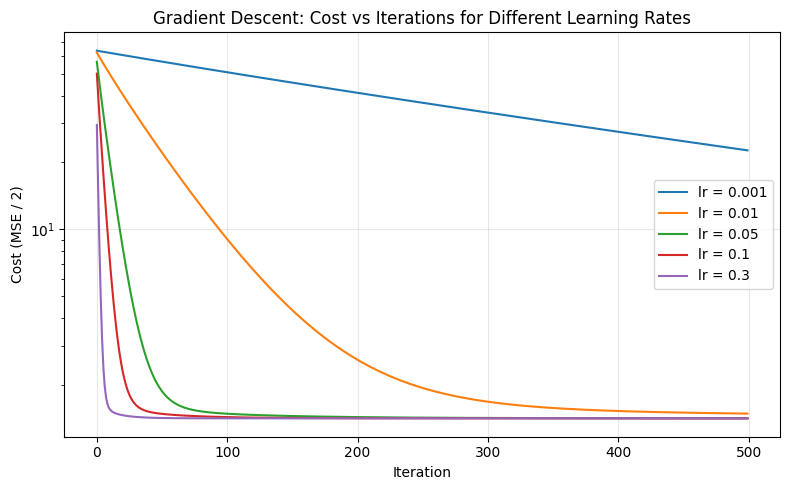

In [26]:
plt.figure(figsize=(8, 5))

for lr, (theta_lr, cost_hist_lr) in results.items():
    plt.plot(cost_hist_lr, label=f"lr = {lr}")

plt.xlabel("Iteration")
plt.ylabel("Cost (MSE / 2)")
plt.title("Gradient Descent: Cost vs Iterations for Different Learning Rates")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:** A very small learning rate (0.001) converges too slowly and the cost is still high after 500 iterations. Learning rates of 0.05 and above converge quickly and settle at a low, stable cost, showing that the model has found a good minimum without diverging.


## Final Model Training

Based on the experiment above, **learning rate = 0.1** gives fast and stable convergence. We retrain the model with this learning rate for a larger number of iterations and use it for evaluation on the test set.


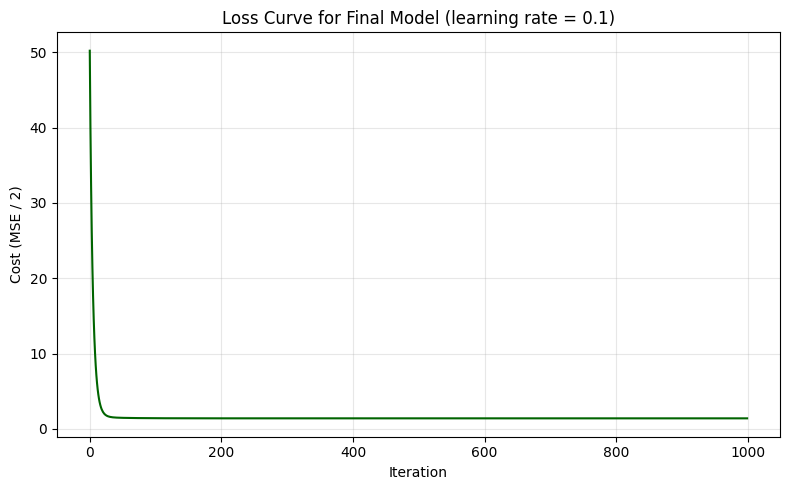

Final training cost: 1.41152717854336


In [27]:
best_lr = 0.1
n_iterations_final = 1000

theta_init = np.zeros((n_features, 1))
theta_best, cost_history_best = gradient_descent(X_train_b, y_train, theta_init,
                                                   best_lr, n_iterations_final)

plt.figure(figsize=(8, 5))
plt.plot(cost_history_best, color="darkgreen")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE / 2)")
plt.title(f"Loss Curve for Final Model (learning rate = {best_lr})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final training cost:", cost_history_best[-1])


In [28]:
# Predictions on the test set
y_pred = X_test_b.dot(theta_best)

# Compare a few actual vs predicted values
comparison = pd.DataFrame({
    "Actual G3": y_test.flatten()[:10],
    "Predicted G3": np.round(y_pred.flatten()[:10], 2)
})
comparison


,Actual G3,Predicted G3
0,10.0,6.00
1,12.0,11.53
2,5.0,2.87
3,10.0,8.80
4,9.0,8.55
5,13.0,11.89
6,18.0,19.10
7,6.0,7.17
8,0.0,7.41
9,14.0,12.31


## Task 8: Evaluate the Model

We evaluate the trained model using four standard regression metrics: **MAE**, **MSE**, **RMSE**, and **R² Score**.


In [29]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


print("Model Evaluation on Test Set")
print("-" * 35)
print(f"MAE  (Mean Absolute Error)      : {mae(y_test, y_pred):.4f}")
print(f"MSE  (Mean Squared Error)       : {mse(y_test, y_pred):.4f}")
print(f"RMSE (Root Mean Squared Error)  : {rmse(y_test, y_pred):.4f}")
print(f"R2   (R-squared Score)          : {r2_score(y_test, y_pred):.4f}")


Model Evaluation on Test Set
-----------------------------------
MAE  (Mean Absolute Error)      : 1.6467
MSE  (Mean Squared Error)       : 5.6567
RMSE (Root Mean Squared Error)  : 2.3784
R2   (R-squared Score)          : 0.7241


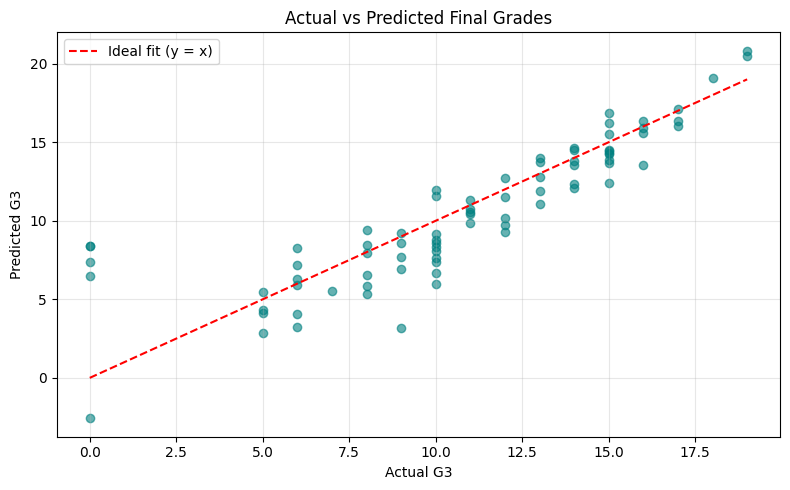

In [30]:
# Visualize actual vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Ideal fit (y = x)")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Task 9: Interpretation and Conclusion

**Convergence behavior:**
- With a very low learning rate (0.001), gradient descent converges too slowly — the cost is still decreasing after 500 iterations and hasn't reached the minimum.
- With moderate to high learning rates (0.05 to 0.3), the model converges quickly (within ~100–200 iterations) and the cost curve flattens out, indicating that gradient descent has found a stable minimum without diverging.
- Learning rate **0.1** was selected as the best trade-off between speed and stability for the final model.

**Prediction performance:**
- The model achieved an **R² score of about 0.72** on the test set, meaning it explains roughly 72% of the variance in students' final grades.
- The **RMSE** of about 2.4 marks indicates the typical prediction error is small relative to the grade scale (0–20).
- The prior period grades `G1` and `G2` are the strongest predictors of the final grade `G3`, which matches intuition — a student's earlier performance strongly indicates their final performance.

**Conclusion:**
Gradient Descent successfully optimized the Linear Regression model to predict students' final grades. The learning rate has a major impact on convergence speed and stability, and standardized features combined with a moderate learning rate (0.1) gave the best convergence and prediction performance in this experiment.
